In [516]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt 
import plotly_express as px 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [517]:
data = yf.download("AAPL", start='2020-01-01', end='2026-04-17')

[*********************100%***********************]  1 of 1 completed


In [518]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400497,72.460761,71.156659,71.409763,135480400
2020-01-03,71.696625,72.455943,71.472447,71.629130,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928047,72.533087,71.708687,72.277571,108872000
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200


In [519]:
data.columns = data.columns.droplevel(1)

In [520]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1580 entries, 2020-01-02 to 2026-04-16
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1580 non-null   float64
 1   High    1580 non-null   float64
 2   Low     1580 non-null   float64
 3   Open    1580 non-null   float64
 4   Volume  1580 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 74.1 KB


In [521]:
# Calculating Price Change
data['Price_Change'] = data['Close'].diff()
data['pct_change'] = data['Close'].pct_change() * 100
data.fillna(0,inplace=True)
data.head(5)

Price,Close,High,Low,Open,Volume,Price_Change,pct_change
Date,,,,,,,
2020-01-02,72.400497,72.460761,71.156659,71.409763,135480400,0.000000,0.000000
2020-01-03,71.696625,72.455943,71.472447,71.629130,146322800,-0.703873,-0.972193
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200,0.571312,0.796846
2020-01-07,71.928047,72.533087,71.708687,72.277571,108872000,-0.339890,-0.470319
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200,1.157074,1.608655


In [522]:
data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Price_Change', 'pct_change'], dtype='object', name='Price')

In [523]:
# Seprating Gain and loss
data["Gain"] = data["Price_Change"].clip(lower=0)
data["Loss"] = -data["Price_Change"].clip(upper=0)

In [524]:
# Rolling Average
data['Avg_Gain'] = data['Gain'].rolling(5).mean()
data['Avg_Loss'] = data['Loss'].rolling(5).mean()

In [525]:
# Moving Average
data['MA_10'] = data['Close'].rolling(10).mean()
data['MA_50'] = data['Close'].rolling(50).mean()

# Volatility
data['Volatility'] = data['Close'].rolling(10).std()

In [526]:
data['Momentum'] = data['Close'] - data['Close'].shift(5)
data['EMA_10'] = data['Close'].ewm(span=10).mean()

In [527]:
ema12 = data['Close'].ewm(span=12).mean()
ema26 = data['Close'].ewm(span=26).mean()
data['MACD'] = ema12 - ema26

In [528]:
data['Volume_Change'] = data['Volume'].pct_change()

In [529]:
# Relative Strength
data['RS'] = data['Avg_Gain'] / data['Avg_Loss']

In [530]:
# RSI 
data['RSI'] = 100 - (100/(1 + data['RS']))

In [531]:
# Signal
data["Signal"] = "HOLD"
data.loc[(data["RSI"] < 30) & (data["RSI"].shift(1) >= 30), "Signal"] = "BUY"
data.loc[(data["RSI"] > 70) & (data["RSI"].shift(1) <= 70), "Signal"] = "SELL"

In [532]:
data.dropna(inplace=True)

In [533]:
data.head(21)

Price,Close,High,Low,Open,Volume,Price_Change,pct_change,Gain,Loss,Avg_Gain,...,MA_10,MA_50,Volatility,Momentum,EMA_10,MACD,Volume_Change,RS,RSI,Signal
Date,,,,,,,,,,,,,,,,,,,,,
2020-03-13,67.164764,67.635938,61.119282,64.004300,370732000,7.185963,11.980837,7.185963,-0.000000,2.363586,...,68.282518,73.801322,3.939964,-2.672386,67.454024,-2.608120,-0.114086,0.815574,44.921010,HOLD
2020-03-16,58.524223,62.600448,57.990228,58.461398,322423600,-8.640541,-12.864693,0.000000,8.640541,2.363586,...,66.914914,73.523796,4.724429,-5.789345,65.830366,-3.153806,-0.130305,0.671196,40.162608,HOLD
2020-03-17,61.097530,62.245250,57.603618,59.804830,324056000,2.573307,4.396995,2.573307,-0.000000,1.951854,...,66.033948,73.311814,4.921712,-7.848003,64.969825,-3.343386,0.005063,0.554275,35.661317,HOLD
2020-03-18,59.601868,60.406482,57.294339,57.934650,300233600,-1.495663,-2.447992,0.000000,1.495663,1.951854,...,64.679153,73.058493,4.599404,-6.949150,63.993809,-3.571120,-0.073513,0.584093,36.872390,HOLD
2020-03-19,59.145184,61.092688,58.620856,59.775827,271857200,-0.456684,-0.766224,0.000000,0.456684,1.951854,...,63.515964,72.802836,4.349978,-0.833618,63.112224,-3.744613,-0.094514,0.921304,47.952015,HOLD
2020-03-20,55.390320,60.848648,55.090702,59.725085,401693200,-3.754864,-6.348554,0.000000,3.754864,0.514661,...,62.071281,72.448940,4.415860,-11.774445,61.708219,-4.133243,0.477589,0.179353,15.207719,BUY
2020-03-23,54.213604,55.211520,51.372085,55.110038,336752800,-1.176716,-2.124407,0.000000,1.176716,0.514661,...,61.061285,72.040462,4.966697,-4.310619,60.345543,-4.483168,-0.161667,0.373814,27.209935,HOLD
2020-03-24,59.652607,59.848323,56.612953,57.110701,287531200,5.439003,10.032543,5.439003,-0.000000,1.087801,...,60.131992,71.737390,4.125797,-1.444923,60.219554,-4.277228,-0.146165,0.790102,44.137257,HOLD
2020-03-25,59.323997,62.399894,59.029214,60.587700,303602000,-0.328609,-0.550872,0.000000,0.328609,1.087801,...,59.409290,71.395781,3.454881,-0.277870,60.056724,-4.093010,0.055892,0.951395,48.754602,HOLD


In [534]:
data.isnull().sum()

Price
Close            0
High             0
Low              0
Open             0
Volume           0
Price_Change     0
pct_change       0
Gain             0
Loss             0
Avg_Gain         0
Avg_Loss         0
MA_10            0
MA_50            0
Volatility       0
Momentum         0
EMA_10           0
MACD             0
Volume_Change    0
RS               0
RSI              0
Signal           0
dtype: int64

In [535]:
data['Target'] = np.where(data['Close'].shift(-3) > data['Close'], "BUY", "SELL")

In [536]:
le = LabelEncoder()
Y = le.fit_transform(data["Target"])

In [537]:
features = ["RSI", "Avg_Gain", "Avg_Loss", "Price_Change", "pct_change","Volatility","MA_10","MA_50","Volume_Change"]

X = data[features]
Y = data["Target"]

In [538]:
# Train test Split 
split = int(len(data)*0.8)

X_train = X[:split]
X_test = X[split:]

Y_train = Y[:split]
Y_test = Y[split:]

In [539]:

train_index = X_train.index
test_index = X_test.index

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X_train = pd.DataFrame(X_train, index=train_index, columns=features)
X_test = pd.DataFrame(X_test, index=test_index, columns=features)

In [540]:
# LogisticRegression 
model_lr = LogisticRegression()
model_lr.fit(X_train,Y_train)

# Prediction
y_pred_lr = model_lr.predict(X_test)

# Accuracy Check
print('Accuracy :', accuracy_score(Y_test,y_pred_lr))

result = pd.DataFrame({
    'Actual': Y_test,
    'Prediction': y_pred_lr
})
result.head()

Accuracy : 0.48859934853420195


,Actual,Prediction
Date,,
2025-01-27,BUY,BUY
2025-01-28,SELL,BUY
2025-01-29,SELL,SELL
2025-01-30,SELL,SELL
2025-01-31,SELL,SELL


In [541]:
# RandomForestClassifier
model_rf = RandomForestClassifier()
model_rf.fit(X_train,Y_train)

#Prediction
y_pred_rf = model_rf.predict(X_test)

#Accuracy check
print('accuracy_score :', accuracy_score(Y_test,y_pred_rf))

#Prediction check
result_rf = pd.DataFrame({
    'Actual':Y_test,
    'Predicted':y_pred_rf
})
result_rf.head()

accuracy_score : 0.5309446254071661


,Actual,Predicted
Date,,
2025-01-27,BUY,BUY
2025-01-28,SELL,BUY
2025-01-29,SELL,BUY
2025-01-30,SELL,BUY
2025-01-31,SELL,BUY


In [542]:
# XGBClassifier
le = LabelEncoder()
Y_train = le.fit_transform(Y_train)
Y_test = le.transform(Y_test)

model_XG = XGBClassifier()
model_XG.fit(X_train,Y_train)

y_pred_xg = model_XG.predict(X_test)

print('Accuracy :',accuracy_score(Y_test,y_pred_xg))

result_xg = pd.DataFrame({
    'Actual':Y_test,
    'Prediction':y_pred_xg
})
result_xg.head()


Accuracy : 0.5407166123778502


,Actual,Prediction
0,0,0
1,1,1
2,1,0
3,1,1
4,1,0


In [543]:
print("Train:", model_XG.score(X_train, Y_train))
print("Test:", model_XG.score(X_test, Y_test))

Train: 1.0
Test: 0.5407166123778502


In [544]:
data.head()

Price,Close,High,Low,Open,Volume,Price_Change,pct_change,Gain,Loss,Avg_Gain,...,MA_50,Volatility,Momentum,EMA_10,MACD,Volume_Change,RS,RSI,Signal,Target
Date,,,,,,,,,,,,,,,,,,,,,
2020-03-13,67.164764,67.635938,61.119282,64.004300,370732000,7.185963,11.980837,7.185963,-0.000000,2.363586,...,73.801322,3.939964,-2.672386,67.454024,-2.608120,-0.114086,0.815574,44.921010,HOLD,SELL
2020-03-16,58.524223,62.600448,57.990228,58.461398,322423600,-8.640541,-12.864693,0.000000,8.640541,2.363586,...,73.523796,4.724429,-5.789345,65.830366,-3.153806,-0.130305,0.671196,40.162608,HOLD,BUY
2020-03-17,61.097530,62.245250,57.603618,59.804830,324056000,2.573307,4.396995,2.573307,-0.000000,1.951854,...,73.311814,4.921712,-7.848003,64.969825,-3.343386,0.005063,0.554275,35.661317,HOLD,SELL
2020-03-18,59.601868,60.406482,57.294339,57.934650,300233600,-1.495663,-2.447992,0.000000,1.495663,1.951854,...,73.058493,4.599404,-6.949150,63.993809,-3.571120,-0.073513,0.584093,36.872390,HOLD,SELL
2020-03-19,59.145184,61.092688,58.620856,59.775827,271857200,-0.456684,-0.766224,0.000000,0.456684,1.951854,...,72.802836,4.349978,-0.833618,63.112224,-3.744613,-0.094514,0.921304,47.952015,HOLD,BUY


In [545]:
Y_test = pd.Series(Y_test, index=X_test.index)
X_test = pd.DataFrame(X_test, index=Y_test.index)

In [546]:
y_pred_final = y_pred_xg
y_pred_final = le.inverse_transform(y_pred_final)

data.loc[X_test.index, 'ML_Signal'] = y_pred_final

In [547]:
def final_signal(row):
    if row['Signal'] == 'BUY' and row['ML_Signal'] == 'BUY':
        return 'STRONG BUY'
    
    elif row['Signal'] == 'SELL' and row['ML_Signal'] == 'SELL':
        return 'STRONG SELL'
    
    elif row['ML_Signal'] == 'BUY':
        return 'WEAK BUY'
    
    elif row['ML_Signal'] == 'SELL':
        return 'WEAK SELL'
    
    else:
        return 'HOLD'
    
data['Final_Signal'] = data.apply(final_signal, axis = 1)

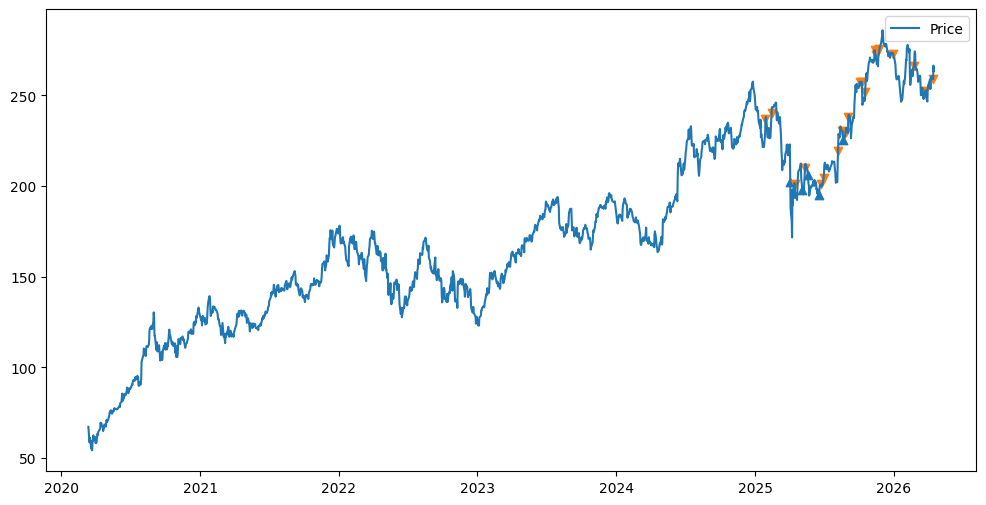

In [548]:
buy = data[data['Final_Signal'] == 'STRONG BUY']
sell = data[data['Final_Signal'] == 'STRONG SELL']

plt.figure(figsize=(12,6))

plt.plot(data['Close'], label='Price')

plt.scatter(buy.index, buy['Close'], marker='^')
plt.scatter(sell.index, sell['Close'], marker='v')

plt.legend()
plt.show()

In [549]:
buy = data[data['Final_Signal'] == 'STRONG BUY']
sell = data[data['Final_Signal'] == 'STRONG SELL']

fig = px.line(data, x=data.index, y='Close', title='Trading Signals')
fig.add_scatter(x=buy.index, y=buy['Close'], mode='markers', 
                marker=dict(symbol='triangle-up', size=10, color='green'), 
                name='STRONG BUY')
fig.add_scatter(x=sell.index, y=sell['Close'], mode='markers', 
                marker=dict(symbol='triangle-down', size=10, color='red'), 
                name='STRONG SELL')
fig.show()


In [550]:
latest = data.iloc[-1]

print("Price:", latest['Close'])
print("RSI Signal:", latest['Signal'])
print("ML Signal:", latest['ML_Signal'])
print("Final Signal:", latest['Final_Signal'])

Price: 263.3999938964844
RSI Signal: HOLD
ML Signal: SELL
Final Signal: WEAK SELL


In [551]:
#confidance score
confidence = 0

if latest['Signal'] == latest['ML_Signal']:
    confidence = 2
elif latest['ML_Signal'] != 'HOLD':
    confidence = 1
else:
    confidence = 0

print("Confidence:", confidence)

Confidence: 1


In [552]:
# Decision Sytem 
if latest['Final_Signal'] == 'STRONG BUY':
    print("ENTER TRADE")
elif latest['Final_Signal'] == 'STRONG SELL':
    print("EXIT / SHORT")
else:
    print("WAIT")

WAIT


In [553]:
#  Backtesting
#Variables
capital = 10000
position = 0 
buy_price = 0
# Loop 
trades = []
for i in range(len(data)):
    signal = data['Final_Signal'].iloc[i]
    price = data['Close'].iloc[i]
    #Buy
    if signal == 'STRONG BUY' and position == 0:
        position = capital / price
        buy_price = price
        capital = 0
        trades.append(('Buy',price))
    #Sell
    elif signal == 'STRONG SELL' and position != 0:
        capital = position * price
        position = 0
        trades.append(('SELL',price, data.index[i]))
    elif position != 0 and price > buy_price * 1.05:
        capital = position * price
        position = 0
        trades.append(('STOP LOSS SELL', price, data.index[i]))

In [554]:
# calculating  value 
if position != 0:
    capital = position * data['Close'].iloc[-1]

print("Final Capital:", capital)

Final Capital: 10487.67155307887


In [555]:
profit = capital - 10000
print("Profit:",profit)

Profit: 487.6715530788697


In [556]:
# Buy pe
capital = capital * (1 - 0.001)

# Sell pe
capital = capital * (1 - 0.001)

In [557]:
print("Total Trades:", len(trades)//2)

Total Trades: 4


In [558]:
profits = []

for i in range(0, len(trades)-1, 2):
    buy_price = trades[i][1]
    sell_price = trades[i+1][1]

    if sell_price > buy_price:
        wins += 1

    total += 1

print("Win Rate:", wins/total if total > 0 else 0)

Win Rate: 0.47619047619047616


In [559]:
returns = (capital - 10000) / 10000
print("Return %:", returns * 100)

Return %: 4.667066976442657
